In [1]:
# Useful starting lines
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2

# Load the data

In [149]:
import datetime
from helpers import *

height, weight, gender = load_data(sub_sample=False, add_outlier=False)
x, mean_x, std_x = standardize(height)
y, tx = build_model_data(x, weight)

In [150]:
y.shape, tx.shape

((10000,), (10000, 2))

### NB: throughout this laboratory the data has the following format: 
  * there are **N = 10000** data entries
  * **y** represents the column vector containing weight information -- that which we wish to predict/the output (see also the first page of $\texttt{exercise02.pdf}$). Its **shape** is **(N,)**.
  * **tx** represents the matrix $\tilde{X}$ formed by laterally concatenating a column vector of 1s to the column vector of height information -- the input data (see also the first page of $\texttt{exercise02.pdf}$). Its **shape** is **(N,2)**.

# 1. Computing the Cost Function
Fill in the `compute_loss` function below:

In [151]:
def compute_loss(y, tx, w):
    """Calculate the loss using either MSE or MAE.

    Args:
        y: numpy array of shape=(N, )
        tx: numpy array of shape=(N,2)
        w: numpy array of shape=(2,). The vector of model parameters.

    Returns:
        the value of the loss (a scalar), corresponding to the input parameters w.
    """
    # ***************************************************
    # INSERT YOUR CODE HERE

    n = len(y)
    e = y - tx.dot(w)

    # Rename function to mse or mae based on what you want
    return compute_mse(e)

    # TODO: compute loss by MSE
    # ***************************************************


In [152]:
def compute_mse(e):
    """Calculate the loss using MSE.

    Args:
        e: numpy array of shape=(N, )

    Returns:
        the value of the loss (a scalar), corresponding to the input parameters w.
    """
    # ***************************************************
    # INSERT YOUR CODE HERE
    loss = e.dot(e)/(2*len(e))
    return loss

    # TODO: compute loss by MSE
    # ***************************************************


In [153]:
def compute_mae(e):
    """Calculate the loss using MAE.

    Args:
        e: numpy array of shape=(N, )

    Returns:
        the value of the loss (a scalar), corresponding to the input parameters w.
    """
    # ***************************************************
    # INSERT YOUR CODE HERE

    loss = np.mean(np.abs(e))
    return loss

    # TODO: compute loss by MAE
    # ***************************************************


In [154]:
compute_loss(y,tx,np.array([71,15]))

np.float64(19.17256408486385)

# 2. Grid Search

Fill in the function `grid_search()` below:

In [155]:
# from costs import *


def grid_search(y, tx, grid_w0, grid_w1):
    """Algorithm for grid search.

    Args:
        y: numpy array of shape=(N, )
        tx: numpy array of shape=(N,2)
        grid_w0: numpy array of shape=(num_grid_pts_w0, ). A 1D array containing num_grid_pts_w0 values of parameter w0 to be tested in the grid search.
        grid_w1: numpy array of shape=(num_grid_pts_w1, ). A 1D array containing num_grid_pts_w1 values of parameter w1 to be tested in the grid search.

    Returns:
        losses: numpy array of shape=(num_grid_pts_w0, num_grid_pts_w1). A 2D array containing the loss value for each combination of w0 and w1
    """

    losses = np.zeros((len(grid_w0), len(grid_w1)))
    # ***************************************************
    # INSERT YOUR CODE HERE
    
    for i in range(len(grid_w0)):
        for j in range(len(grid_w1)):
            losses[i,j] = compute_loss (y,tx,np.array([grid_w0[i],grid_w1[j]]))

    # TODO: compute loss for each combination of w0 and w1.
    # ***************************************************
    return losses

Let us play with the grid search demo now!

Grid Search: loss*=15.397905708213628, w0*=73.14629258517036, w1*=13.527054108216447, execution time=2.819 seconds


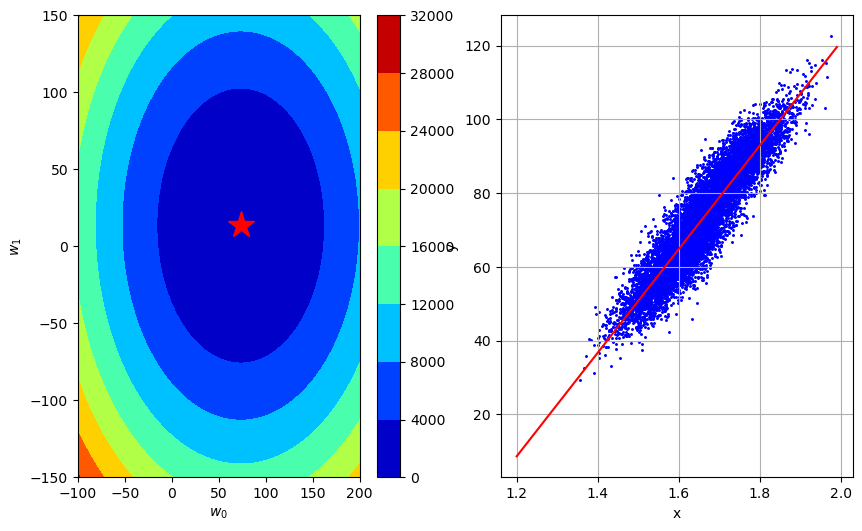

In [156]:
from grid_search import generate_w, get_best_parameters
from plots import grid_visualization

# Generate the grid of parameters to be swept
grid_w0, grid_w1 = generate_w(num_intervals=500)

# Start the grid search
start_time = datetime.datetime.now()
grid_losses = grid_search(y, tx, grid_w0, grid_w1)

# Select the best combinaison
loss_star, w0_star, w1_star = get_best_parameters(grid_w0, grid_w1, grid_losses)
end_time = datetime.datetime.now()
execution_time = (end_time - start_time).total_seconds()

# Print the results
print(
    "Grid Search: loss*={l}, w0*={w0}, w1*={w1}, execution time={t:.3f} seconds".format(
        l=loss_star, w0=w0_star, w1=w1_star, t=execution_time
    )
)

# Plot the results
fig = grid_visualization(grid_losses, grid_w0, grid_w1, mean_x, std_x, height, weight)
fig.set_size_inches(10.0, 6.0)
fig.savefig("grid_plot")  # Optional saving

# 3. Gradient Descent

Again, please fill in the functions `compute_gradient` below:

In [157]:
def compute_gradient(y, tx, w):
    """Computes the gradient at w.

    Args:
        y: numpy array of shape=(N, )
        tx: numpy array of shape=(N,2)
        w: numpy array of shape=(2, ). The vector of model parameters.

    Returns:
        An numpy array of shape (2, ) (same shape as w), containing the gradient of the loss at w.
    """
    # ***************************************************
    # INSERT YOUR CODE HERE

    n = len(y)
    e = y - tx.dot(w)
    grad = (-1/n)*tx.T.dot(e)
    return grad



    # TODO: compute gradient vector
    # ***************************************************
    raise NotImplementedError

In [158]:
compute_gradient(y, tx, np.array([70,20]))

array([-3.293922  ,  6.52028757])

Please fill in the functions `gradient_descent` below:

In [159]:
def gradient_descent(y, tx, initial_w, max_iters, gamma):
    """The Gradient Descent (GD) algorithm.

    Args:
        y: numpy array of shape=(N, )
        tx: numpy array of shape=(N,2)
        initial_w: numpy array of shape=(2, ). The initial guess (or the initialization) for the model parameters
        max_iters: a scalar denoting the total number of iterations of GD
        gamma: a scalar denoting the stepsize

    Returns:
        losses: a list of length max_iters containing the loss value (scalar) for each iteration of GD
        ws: a list of length max_iters + 1 containing the model parameters as numpy arrays of shape (2, ),
            for each iteration of GD (as well as the final weights)
    """
    # Define parameters to store w and loss
    ws = [initial_w]
    losses = []
    w = initial_w
    for n_iter in range(max_iters):
        # ***************************************************
        # INSERT YOUR CODE HERE

        loss = compute_loss(y,tx,w)
        grad = compute_gradient(y,tx,w)

        # TODO: compute gradient and loss
        # ***************************************************
        # INSERT YOUR CODE HERE
        
        w = w - gamma*grad

        # TODO: update w by gradient
        # ***************************************************
        # store w and loss
        ws.append(w)
        losses.append(loss)
        print(
            "GD iter. {bi}/{ti}: loss={l}, w0={w0}, w1={w1}".format(
                bi=n_iter, ti=max_iters - 1, l=loss, w0=w[0], w1=w[1]
            )
        )

    return losses, ws

Test your gradient descent function through gradient descent demo shown below:

In [160]:
# from gradient_descent import *
from plots import gradient_descent_visualization

# Define the parameters of the algorithm.
max_iters = 50
gamma = 0.1

# Initialization
w_initial = np.array([0, 0])

# Start gradient descent.
start_time = datetime.datetime.now()
gd_losses, gd_ws = gradient_descent(y, tx, w_initial, max_iters, gamma)
end_time = datetime.datetime.now()

# Print result
exection_time = (end_time - start_time).total_seconds()
print("GD: execution time={t:.3f} seconds".format(t=exection_time))

GD iter. 0/49: loss=2792.2367127591656, w0=7.329392200210527, w1=1.3479712434989437
GD iter. 1/49: loss=2264.635056030001, w0=13.925845180399985, w1=2.561145362647994
GD iter. 2/49: loss=1837.2777140793778, w0=19.862652862570517, w1=3.6530020698821186
GD iter. 3/49: loss=1491.1182670993726, w0=25.205779776523993, w1=4.635673106392836
GD iter. 4/49: loss=1210.7291150455694, w0=30.014593999082106, w1=5.520077039252476
GD iter. 5/49: loss=983.6139018819887, w0=34.3425267993844, w1=6.316040578826146
GD iter. 6/49: loss=799.6505792194879, w0=38.237666319656476, w1=7.032407764442448
GD iter. 7/49: loss=650.640287862863, w0=41.74329188790135, w1=7.6771382314971195
GD iter. 8/49: loss=529.9419518639963, w0=44.898354899321745, w1=8.25739565184632
GD iter. 9/49: loss=432.1762997049138, w0=47.73791160960009, w1=8.779627330160602
GD iter. 10/49: loss=352.9861214560578, w0=50.293512648850594, w1=9.249635840643457
GD iter. 11/49: loss=288.8420770744843, w0=52.59355358417605, w1=9.672643500078022
GD 

interactive(children=(IntSlider(value=1, description='n_iter', max=51, min=1), Output()), _dom_classes=('widge…

<function __main__.plot_figure(n_iter)>

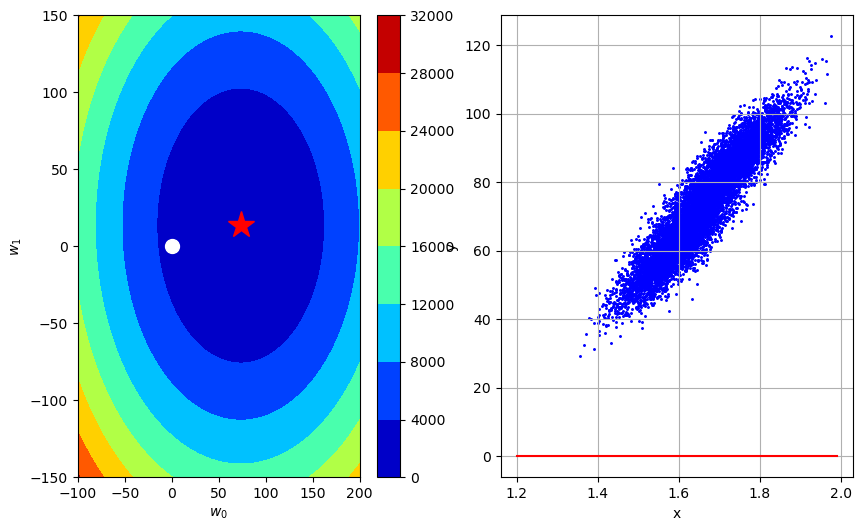

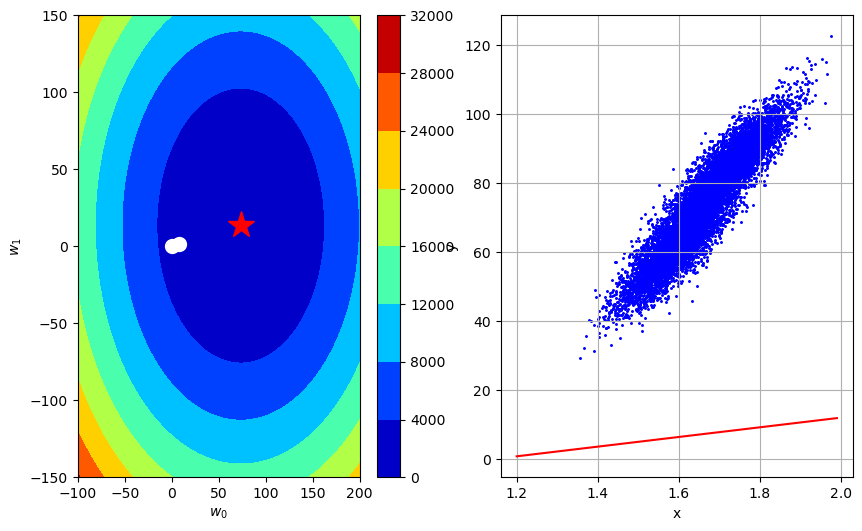

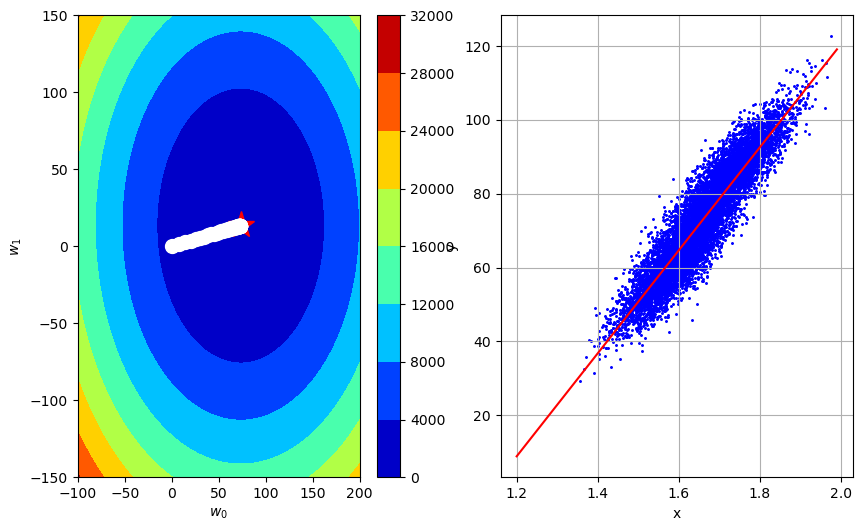

In [161]:
# Time Visualization
from ipywidgets import IntSlider, interact


def plot_figure(n_iter):
    fig = gradient_descent_visualization(
        gd_losses,
        gd_ws,
        grid_losses,
        grid_w0,
        grid_w1,
        mean_x,
        std_x,
        height,
        weight,
        n_iter,
    )
    fig.set_size_inches(10.0, 6.0)


interact(plot_figure, n_iter=IntSlider(min=1, max=len(gd_ws)))

# 4. Stochastic gradient descent

In [162]:
def compute_stoch_gradient(y, tx, w):
    """Compute a stochastic gradient at w from a data sample batch of size B, where B < N, and their corresponding labels.

    Args:
        y: numpy array of shape=(B, )
        tx: numpy array of shape=(B,2)
        w: numpy array of shape=(2, ). The vector of model parameters.

    Returns:
        A numpy array of shape (2, ) (same shape as w), containing the stochastic gradient of the loss at w.
    """

    # ***************************************************
    # INSERT YOUR CODE HERE

    n = len(y)
    e = y - tx.dot(w)
    grad = (-1/n)*tx.T.dot(e)

    return grad



    # TODO: implement stochastic gradient computation. It's the same as the usual gradient.
    # ***************************************************
    raise NotImplementedError


def stochastic_gradient_descent(y, tx, initial_w, batch_size, max_iters, gamma):
    """The Stochastic Gradient Descent algorithm (SGD).

    Args:
        y: numpy array of shape=(N, )
        tx: numpy array of shape=(N,2)
        initial_w: numpy array of shape=(2, ). The initial guess (or the initialization) for the model parameters
        batch_size: a scalar denoting the number of data points in a mini-batch used for computing the stochastic gradient
        max_iters: a scalar denoting the total number of iterations of SGD
        gamma: a scalar denoting the stepsize

    Returns:
        losses: a list of length max_iters containing the loss value (scalar) for each iteration of SGD
        ws: a list of length max_iters containing the model parameters as numpy arrays of shape (2, ), for each iteration of SGD
    """

    # Define parameters to store w and loss
    ws = [initial_w]
    losses = []
    w = initial_w

    for n_iter in range(max_iters):
        # ***************************************************
        # INSERT YOUR CODE HERE

        for minibatch_y, minibatch_tx in batch_iter(y, tx, batch_size):
            grad = compute_stoch_gradient(minibatch_y,minibatch_tx,w)
            w = w - gamma*grad
        loss = compute_loss(y,tx,w)
        ws.append(w)
        losses.append(loss)


        # TODO: implement stochastic gradient descent.
        # ***************************************************

        print(
            "SGD iter. {bi}/{ti}: loss={l}, w0={w0}, w1={w1}".format(
                bi=n_iter, ti=max_iters - 1, l=loss, w0=w[0], w1=w[1]
            )
        )
    return losses, ws

In [163]:
# from stochastic_gradient_descent import *

# Define the parameters of the algorithm.
max_iters = 50
gamma = 0.1
batch_size = 1

# Initialization
w_initial = np.array([0, 0])

# Start SGD.
start_time = datetime.datetime.now()
sgd_losses, sgd_ws = stochastic_gradient_descent(
    y, tx, w_initial, batch_size, max_iters, gamma
)
end_time = datetime.datetime.now()

# Print result
exection_time = (end_time - start_time).total_seconds()
print("SGD: execution time={t:.3f} seconds".format(t=exection_time))

SGD iter. 0/49: loss=2489.5385149898766, w0=6.204750310351216, w1=-7.670897389705158
SGD iter. 1/49: loss=1825.712008303061, w0=14.79611724172653, w1=-0.6149347434643673
SGD iter. 2/49: loss=1421.0921195972194, w0=21.82161771199958, w1=0.7512264871806378
SGD iter. 3/49: loss=1291.0952951619956, w0=25.70369308926451, w1=-3.4492251161319887
SGD iter. 4/49: loss=1156.0370329822836, w0=29.647407982182262, w1=-5.918331387406527
SGD iter. 5/49: loss=781.4597654746497, w0=36.60878388333753, w1=-0.17123611881413847
SGD iter. 6/49: loss=752.388052003493, w0=38.71324311623065, w1=-3.199045794008673
SGD iter. 7/49: loss=678.1238283159548, w0=41.39597178444129, w1=-4.070120977487753
SGD iter. 8/49: loss=450.4417832559548, w0=46.59933242485274, w1=0.9293866194455935
SGD iter. 9/49: loss=349.99906460273155, w0=50.221134687754244, w1=1.7804458334224735
SGD iter. 10/49: loss=332.18500135307545, w0=51.73015847806953, w1=0.4950164567243942
SGD iter. 11/49: loss=329.60870521927865, w0=51.22687829488085, 

interactive(children=(IntSlider(value=1, description='n_iter', max=51, min=1), Output()), _dom_classes=('widge…

<function __main__.plot_figure(n_iter)>

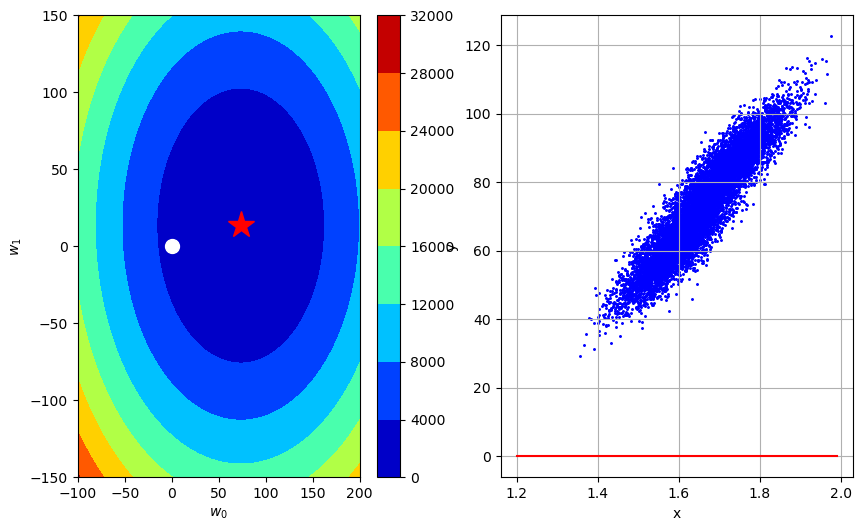

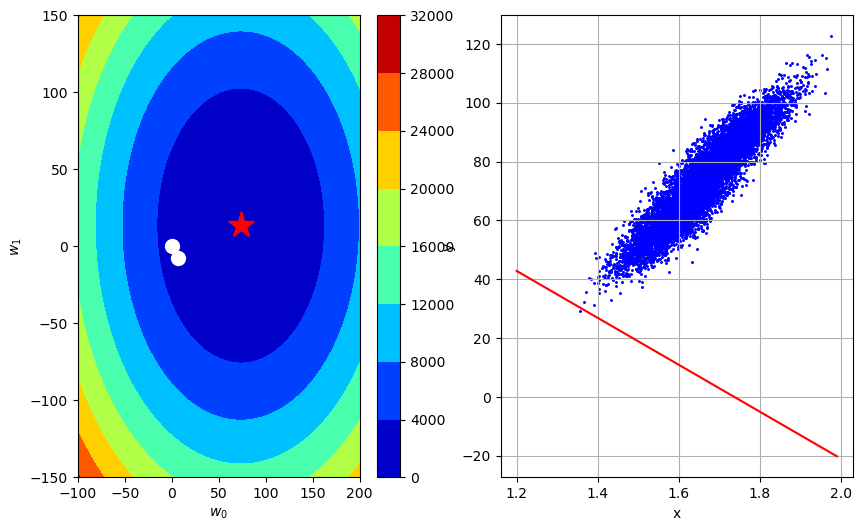

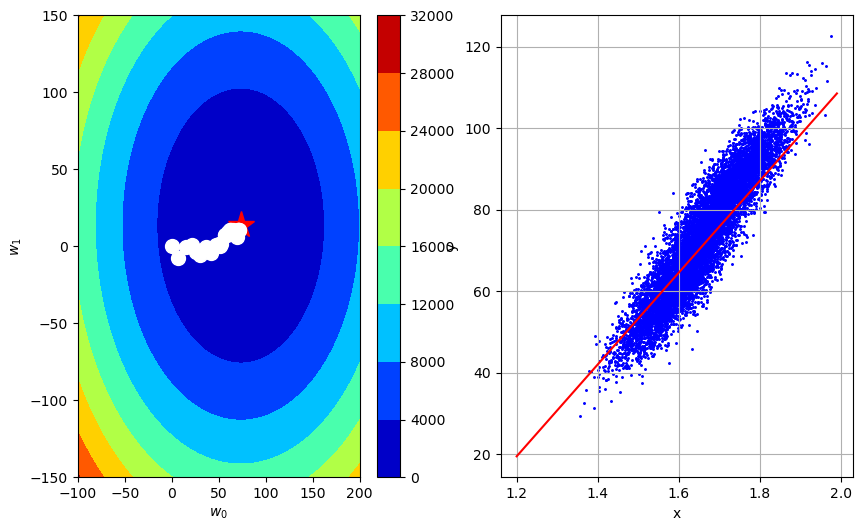

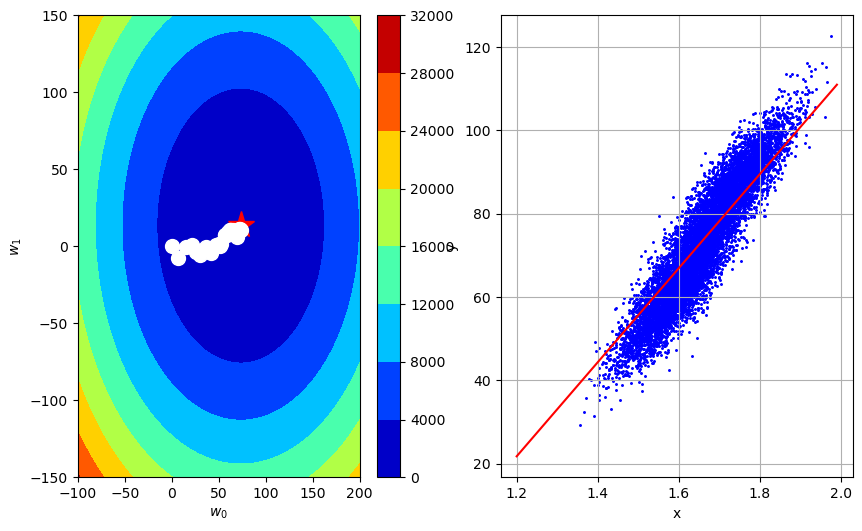

In [164]:
# Time Visualization
from ipywidgets import IntSlider, interact


def plot_figure(n_iter):
    fig = gradient_descent_visualization(
        sgd_losses,
        sgd_ws,
        grid_losses,
        grid_w0,
        grid_w1,
        mean_x,
        std_x,
        height,
        weight,
        n_iter,
    )
    fig.set_size_inches(10.0, 6.0)


interact(plot_figure, n_iter=IntSlider(min=1, max=len(sgd_ws)))

# 5. Effect of Outliers and MAE Cost Function

In [116]:
import datetime
from helpers import *

# ***************************************************
# INSERT YOUR CODE HERE

height, weight, gender = load_data(sub_sample=True, add_outlier=True)

# TODO: reload the data by subsampling first, then by subsampling and adding outliers
# ***************************************************

x, mean_x, std_x = standardize(height)
y, tx = build_model_data(x, weight)

In [117]:
y.shape, tx.shape

((202,), (202, 2))

In [130]:
from plots import gradient_descent_visualization

# Define the parameters of the algorithm.
max_iters = 500
gamma = 0.7

# Initialization
w_initial = np.array([0, 0])

# Start gradient descent.
start_time = datetime.datetime.now()

# ***************************************************
# INSERT YOUR CODE HERE


gd_losses, gd_ws = gradient_descent(y, tx, w_initial, max_iters, gamma)



# TODO: fit the model to the subsampled data / subsampled data with outliers and visualize the cloud of points
#       and the model fit
# ***************************************************


end_time = datetime.datetime.now()

# Print result
exection_time = (end_time - start_time).total_seconds()
print("GD: execution time={t:.3f} seconds".format(t=exection_time))

GD iter. 0/499: loss=74.06780585492638, w0=51.847464098448484, w1=7.724426406192441
GD iter. 1/499: loss=22.220341756477886, w0=67.401703327983, w1=10.041754328050121
GD iter. 2/499: loss=8.540676439415343, w0=72.06797509684336, w1=10.736952704607413
GD iter. 3/499: loss=6.904828366810239, w0=73.46785662750146, w1=10.945512217574594
GD iter. 4/499: loss=6.674709716875214, w0=73.88782108669889, w1=11.00808007146475
GD iter. 5/499: loss=6.644814813344382, w0=74.01381042445813, w1=11.026850427631796
GD iter. 6/499: loss=6.639117501635084, w0=74.05160722578589, w1=11.03248153448191
GD iter. 7/499: loss=6.637802926368862, w0=74.06294626618423, w1=11.034170866536943
GD iter. 8/499: loss=6.637503390841277, w0=74.06634797830372, w1=11.034677666153454
GD iter. 9/499: loss=6.637417848906233, w0=74.06736849193958, w1=11.034829706038407
GD iter. 10/499: loss=6.637392186325722, w0=74.06767464603033, w1=11.034875318003893
GD iter. 11/499: loss=6.637384487551568, w0=74.06776649225756, w1=11.034889001

interactive(children=(IntSlider(value=1, description='n_iter', max=501, min=1), Output()), _dom_classes=('widg…

<function __main__.plot_figure(n_iter)>

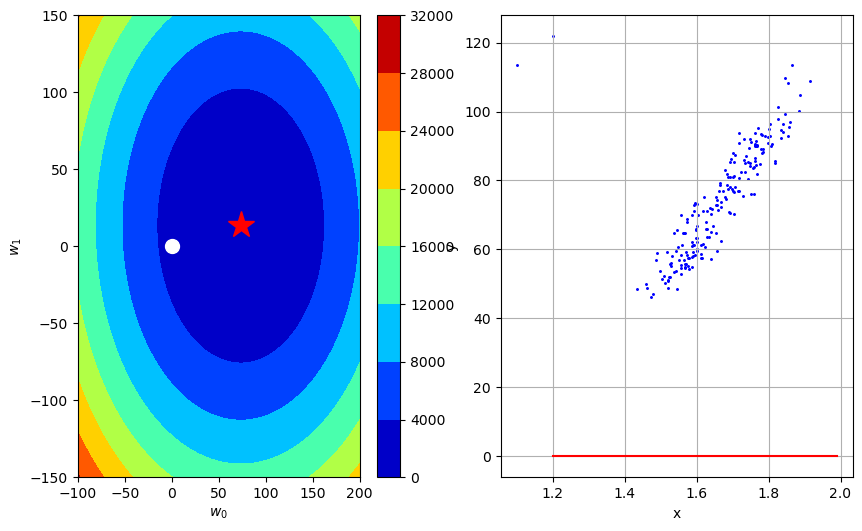

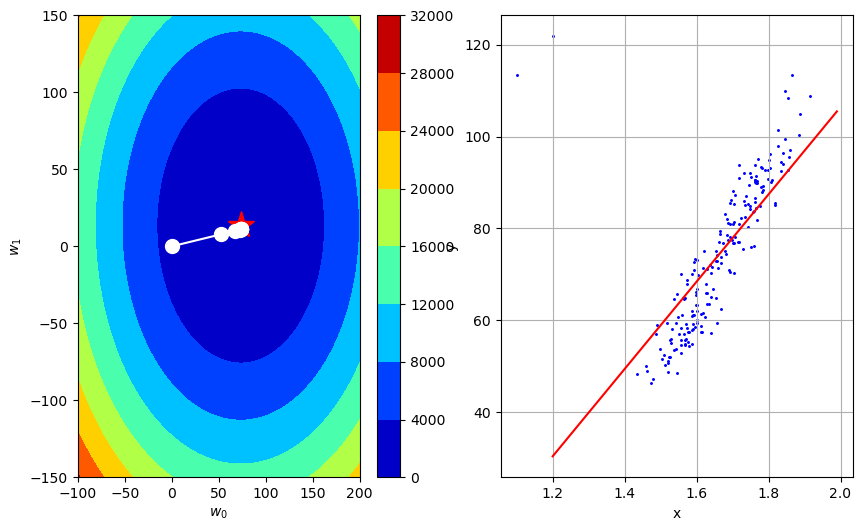

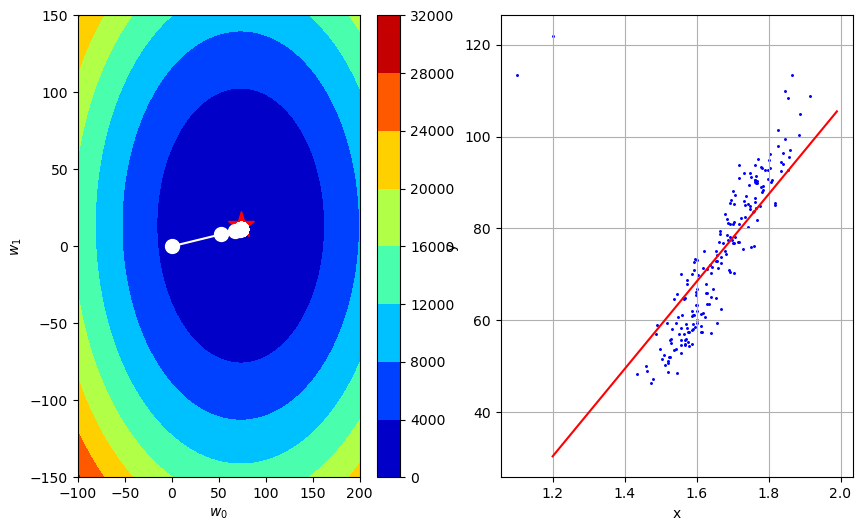

In [131]:
# Time Visualization
from ipywidgets import IntSlider, interact


def plot_figure(n_iter):
    fig = gradient_descent_visualization(
        gd_losses,
        gd_ws,
        grid_losses,
        grid_w0,
        grid_w1,
        mean_x,
        std_x,
        height,
        weight,
        n_iter,
    )
    fig.set_size_inches(10.0, 6.0)


interact(plot_figure, n_iter=IntSlider(min=1, max=len(gd_ws)))

# 6. Subgradient descent

In [126]:
def compute_subgradient_mae(y, tx, w):
    """Compute a subgradient of the MAE at w.

    Args:
        y: numpy array of shape=(N, )
        tx: numpy array of shape=(N,2)
        w: numpy array of shape=(2, ). The vector of model parameters.

    Returns:
        A numpy array of shape (2, ) (same shape as w), containing the subgradient of the MAE at w.
    """
    # ***************************************************
    # INSERT YOUR CODE HERE

    n = len(y)
    e = y - tx.dot(w)
    grad = (-1/n)*tx.T.dot(np.sign(e))
    return grad


    # TODO: compute subgradient gradient vector for MAE
    # ***************************************************
    raise NotImplementedError

In [127]:
def subgradient_descent(y, tx, initial_w, max_iters, gamma):
    """The SubGradient Descent (SubGD) algorithm.

    Args:
        y: numpy array of shape=(N, )
        tx: numpy array of shape=(N,2)
        initial_w: numpy array of shape=(2, ). The initial guess (or the initialization) for the model parameters
        max_iters: a scalar denoting the total number of iterations of GD
        gamma: a scalar denoting the stepsize

    Returns:
        losses: a list of length max_iters containing the loss value (scalar) for each iteration of SubGD
        ws: a list of length max_iters containing the model parameters as numpy arrays of shape (2, ), for each iteration of SubGD
    """
    # Define parameters to store w and loss
    ws = [initial_w]
    losses = []
    w = initial_w
    for n_iter in range(max_iters):
        # ***************************************************
        # INSERT YOUR CODE HERE

        loss = compute_loss(y,tx,w)
        grad = compute_subgradient_mae(y,tx,w)

        # TODO: compute subgradient and loss
        # ***************************************************
        # INSERT YOUR CODE HERE

        w = w - gamma*grad

        # TODO: update w by subgradient
        # ***************************************************

        ws.append(w)
        losses.append(loss)
        print(
            "SubGD iter. {bi}/{ti}: loss={l}, w0={w0}, w1={w1}".format(
                bi=n_iter, ti=max_iters - 1, l=loss, w0=w[0], w1=w[1]
            )
        )

    return losses, ws

In [128]:
# Define the parameters of the algorithm.
max_iters = 500
gamma = 0.7
batch_size = 1

# Initialization
w_initial = np.array([0, 0])

# Start SubSGD.
start_time = datetime.datetime.now()
subgd_losses, subgd_ws = subgradient_descent(y, tx, w_initial, max_iters, gamma)
end_time = datetime.datetime.now()

# Print result
exection_time = (end_time - start_time).total_seconds()
print("SubGD: execution time={t:.3f} seconds".format(t=exection_time))

SubGD iter. 0/499: loss=74.06780585492638, w0=0.7, w1=8.756471895211877e-16
SubGD iter. 1/499: loss=73.36780585492637, w0=1.4, w1=1.7512943790423754e-15
SubGD iter. 2/499: loss=72.66780585492637, w0=2.0999999999999996, w1=2.626941568563563e-15
SubGD iter. 3/499: loss=71.96780585492637, w0=2.8, w1=3.502588758084751e-15
SubGD iter. 4/499: loss=71.26780585492638, w0=3.5, w1=4.378235947605939e-15
SubGD iter. 5/499: loss=70.56780585492638, w0=4.2, w1=5.253883137127127e-15
SubGD iter. 6/499: loss=69.86780585492637, w0=4.9, w1=6.1295303266483146e-15
SubGD iter. 7/499: loss=69.16780585492639, w0=5.6000000000000005, w1=7.0051775161695025e-15
SubGD iter. 8/499: loss=68.46780585492638, w0=6.300000000000001, w1=7.88082470569069e-15
SubGD iter. 9/499: loss=67.76780585492638, w0=7.000000000000001, w1=8.756471895211878e-15
SubGD iter. 10/499: loss=67.06780585492638, w0=7.700000000000001, w1=9.632119084733065e-15
SubGD iter. 11/499: loss=66.36780585492637, w0=8.4, w1=1.0507766274254253e-14
SubGD iter.

interactive(children=(IntSlider(value=1, description='n_iter', max=501, min=1), Output()), _dom_classes=('widg…

<function __main__.plot_figure(n_iter)>

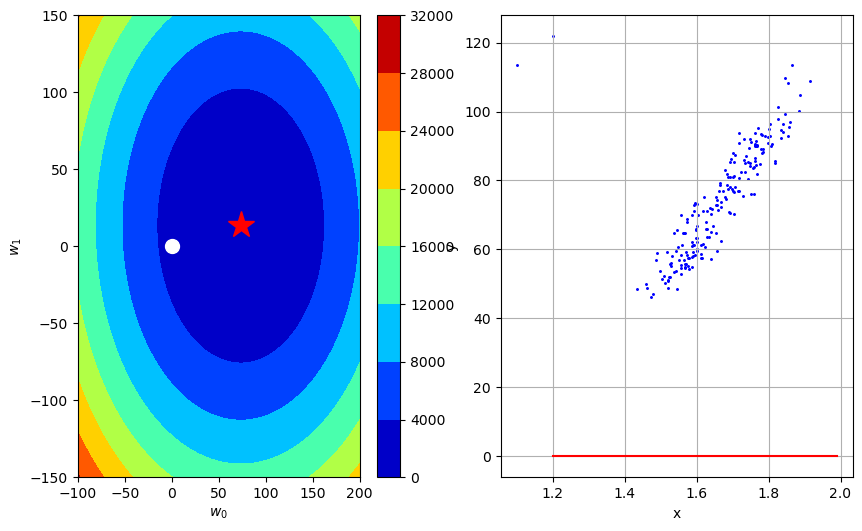

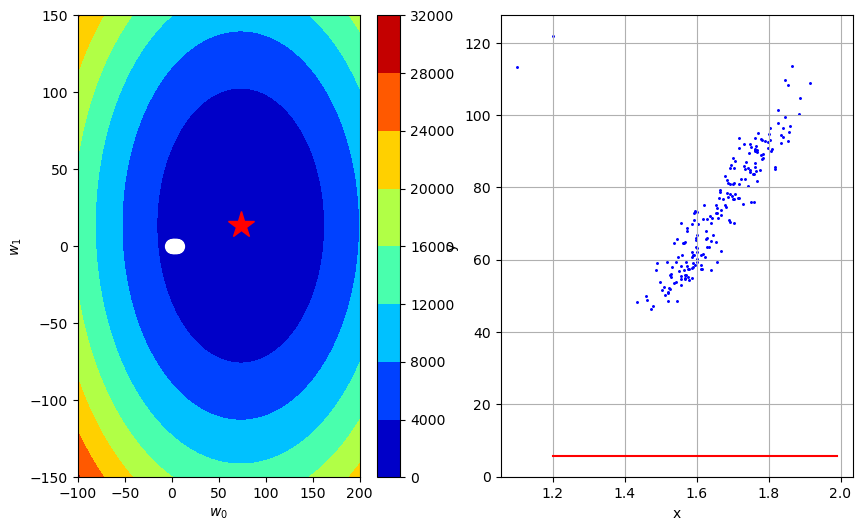

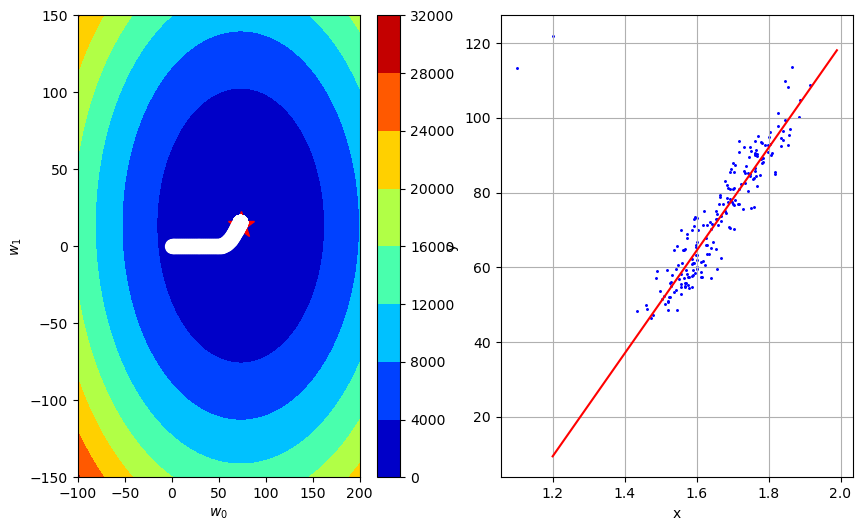

In [129]:
from ipywidgets import IntSlider, interact


def plot_figure(n_iter):
    fig = gradient_descent_visualization(
        subgd_losses,
        subgd_ws,
        grid_losses,
        grid_w0,
        grid_w1,
        mean_x,
        std_x,
        height,
        weight,
        n_iter,
    )
    fig.set_size_inches(10.0, 6.0)


interact(plot_figure, n_iter=IntSlider(min=1, max=len(subgd_ws)))

# Stochastic Subgradient Descent

**NB** for the computation of the subgradient you can reuse the `compute_subgradient` method that you implemented above, just making sure that you pass in a minibatch as opposed to the full data.

In [132]:
def stochastic_subgradient_descent(y, tx, initial_w, batch_size, max_iters, gamma):
    """Compute a stochastic subgradient at w from a data sample batch of size B, where B < N, and their corresponding labels.

    Args:
        y: numpy array of shape=(B, )
        tx: numpy array of shape=(B,2)
        initial_w: numpy array of shape=(2, ). The initial guess (or the initialization) for the model parameters
        batch_size: a scalar denoting the number of data points in a mini-batch used for computing the stochastic subgradient
        max_iters: a scalar denoting the total number of iterations of SubSGD
        gamma: a scalar denoting the stepsize

    Returns:
        losses: a list of length max_iters containing the loss value (scalar) for each iteration of SubSGD
        ws: a list of length max_iters containing the model parameters as numpy arrays of shape (2, ), for each iteration of SubSGD
    """

    # Define parameters to store w and loss
    ws = [initial_w]
    losses = []
    w = initial_w

    for n_iter in range(max_iters):
        # ***************************************************
        # INSERT YOUR CODE HERE
        for minibatch_y, minibatch_tx in batch_iter(y, tx, batch_size):
            grad = compute_subgradient_mae(minibatch_y,minibatch_tx,w)
            w = w - gamma*grad
        loss = compute_loss(y,tx,w)
        ws.append(w)
        losses.append(loss)
        # TODO: implement stochastic subgradient descent.
        # ***************************************************

        print(
            "SubSGD iter. {bi}/{ti}: loss={l}, w0={w0}, w1={w1}".format(
                bi=n_iter, ti=max_iters - 1, l=loss, w0=w[0], w1=w[1]
            )
        )
    return losses, ws

In [133]:
# Define the parameters of the algorithm.
max_iters = 500
gamma = 0.7
batch_size = 1

# Initialization
w_initial = np.array([0, 0])

# Start SubSGD.
start_time = datetime.datetime.now()
subsgd_losses, subsgd_ws = stochastic_subgradient_descent(
    y, tx, w_initial, batch_size, max_iters, gamma
)
end_time = datetime.datetime.now()

# Print result
exection_time = (end_time - start_time).total_seconds()
print("SubSGD: execution time={t:.3f} seconds".format(t=exection_time))

SubSGD iter. 0/499: loss=73.36780585492637, w0=0.7, w1=0.5923179612681783
SubSGD iter. 1/499: loss=72.66780585492637, w0=1.4, w1=0.16130727651956456
SubSGD iter. 2/499: loss=71.96780585492638, w0=2.0999999999999996, w1=-0.07967263814708359
SubSGD iter. 3/499: loss=71.26780585492638, w0=2.8, w1=-0.04238532652921387
SubSGD iter. 4/499: loss=70.56780585492638, w0=3.5, w1=0.15413475624928885
SubSGD iter. 5/499: loss=69.86780585492637, w0=4.2, w1=-0.7893717272878314
SubSGD iter. 6/499: loss=69.16780585492639, w0=4.9, w1=-0.18396857584384685
SubSGD iter. 7/499: loss=68.46780585492638, w0=5.6000000000000005, w1=0.7629436858985835
SubSGD iter. 8/499: loss=67.76780585492638, w0=6.300000000000001, w1=2.0022599868765845
SubSGD iter. 9/499: loss=67.06780585492638, w0=7.000000000000001, w1=1.5625715817914
SubSGD iter. 10/499: loss=66.36780585492637, w0=7.700000000000001, w1=0.8659868305506374
SubSGD iter. 11/499: loss=65.66780585492639, w0=8.4, w1=-0.4879700634825902
SubSGD iter. 12/499: loss=64.96

interactive(children=(IntSlider(value=1, description='n_iter', max=501, min=1), Output()), _dom_classes=('widg…

<function __main__.plot_figure(n_iter)>

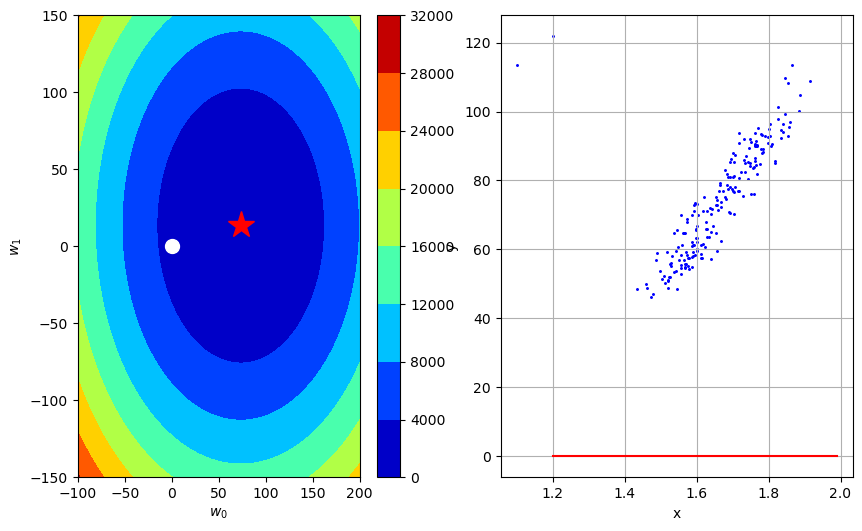

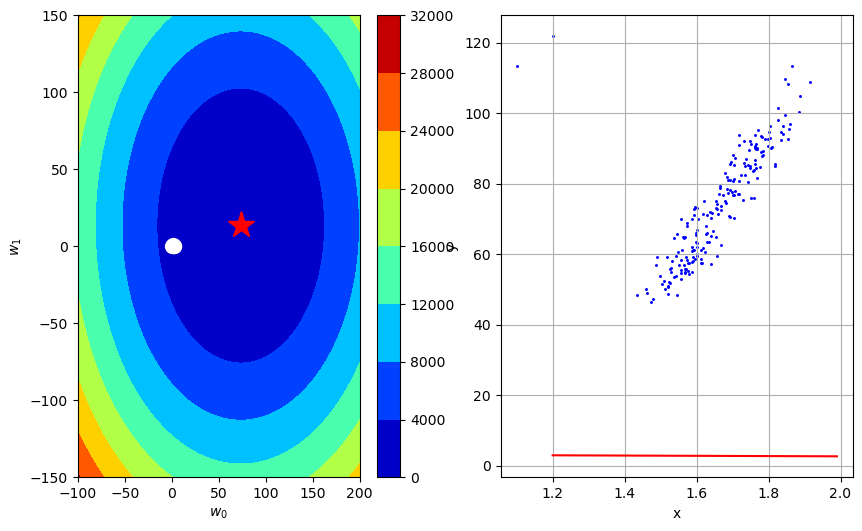

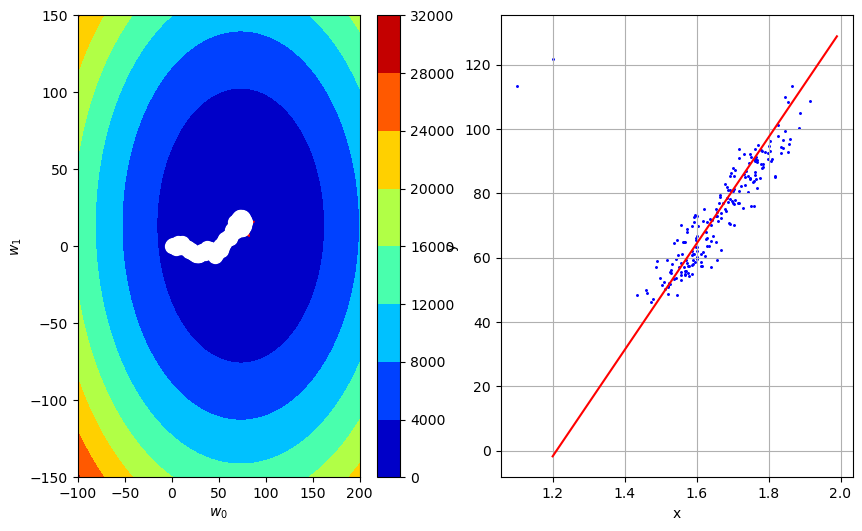

In [134]:
from ipywidgets import IntSlider, interact


def plot_figure(n_iter):
    fig = gradient_descent_visualization(
        subsgd_losses,
        subsgd_ws,
        grid_losses,
        grid_w0,
        grid_w1,
        mean_x,
        std_x,
        height,
        weight,
        n_iter,
    )
    fig.set_size_inches(10.0, 6.0)


interact(plot_figure, n_iter=IntSlider(min=1, max=len(subsgd_ws)))